In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("dataset.csv")

print(df.shape)
df.head()

(1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


Shape: (1014, 7)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB

Missing values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Class distribution:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


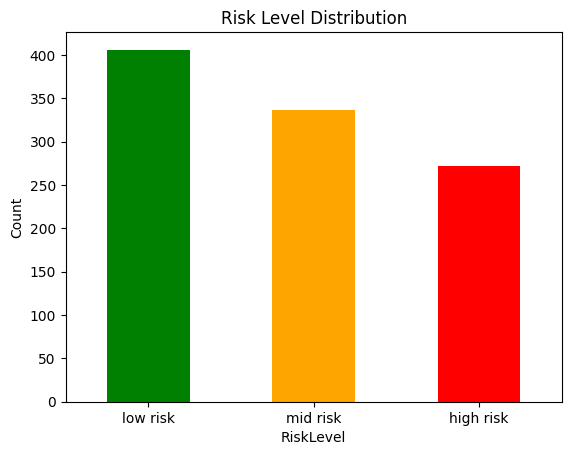

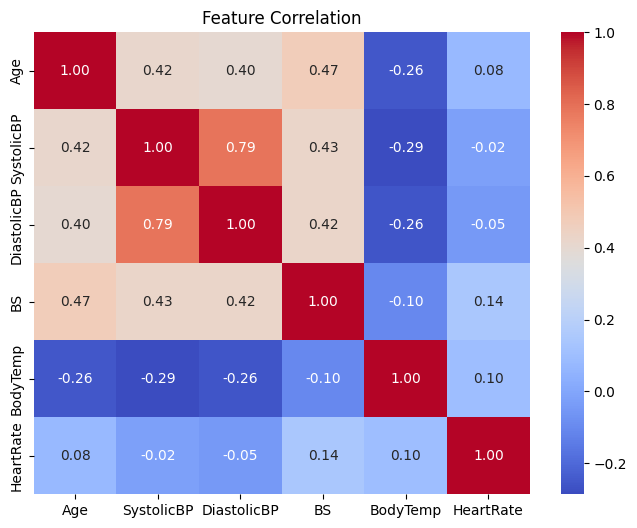

In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["RiskLevel"].value_counts())

# Plot class distribution
df["RiskLevel"].value_counts().plot(kind="bar", color=["green","orange","red"])
plt.title("Risk Level Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop("RiskLevel", axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [4]:
# Encode target label
le = LabelEncoder()
df["RiskLabel"] = le.fit_transform(df["RiskLevel"])
# Output: high risk=0, low risk=1, mid risk=2 (alphabetical by default)
print("Classes:", le.classes_)   # ['high risk', 'low risk', 'mid risk']

X = df.drop(["RiskLevel", "RiskLabel"], axis=1)
y = df["RiskLabel"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Classes: ['high risk' 'low risk' 'mid risk']
Train size: (811, 6)
Test size: (203, 6)


In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "SVM":                 SVC(random_state=42),
    "KNN":                 KNeighborsClassifier(),
}

results = {}

for name, model in models.items():
    # Wrap in pipeline with scaler
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])
    
    # 5-fold cross-validation
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
    results[name] = {
        "mean": cv_scores.mean(),
        "std": cv_scores.std()
    }
    print(f"{name:25s} → CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Find best model
best_name = max(results, key=lambda k: results[k]["mean"])
print(f"\n🏆 Best model: {best_name} ({results[best_name]['mean']:.4f})")

Logistic Regression       → CV Accuracy: 0.6202 ± 0.0204
Decision Tree             → CV Accuracy: 0.8138 ± 0.0244
Random Forest             → CV Accuracy: 0.8212 ± 0.0201
Gradient Boosting         → CV Accuracy: 0.7719 ± 0.0142
SVM                       → CV Accuracy: 0.6991 ± 0.0156
KNN                       → CV Accuracy: 0.6843 ± 0.0172

🏆 Best model: Random Forest (0.8212)


In [6]:
# If Random Forest wins, tune it; adapt if another model wins
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 5, 10, 15],
    "clf__min_samples_split": [2, 5, 10],
}

best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    best_pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'clf__max_depth': 15, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best CV score: 0.8273725668408695


Test Accuracy: 0.8669950738916257

Classification Report:
              precision    recall  f1-score   support

   high risk       0.96      0.95      0.95        55
    low risk       0.88      0.83      0.85        81
    mid risk       0.78      0.85      0.81        67

    accuracy                           0.87       203
   macro avg       0.88      0.87      0.87       203
weighted avg       0.87      0.87      0.87       203



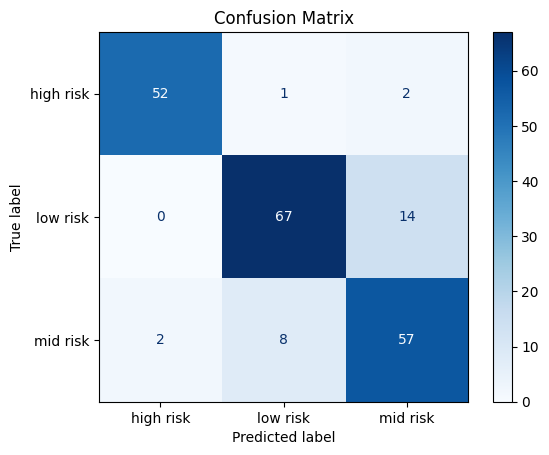

In [7]:
final_model = grid_search.best_estimator_
y_pred = final_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

C:\Users\jevonnn\AppData\Local\Temp\ipykernel_50528\37378729.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis")


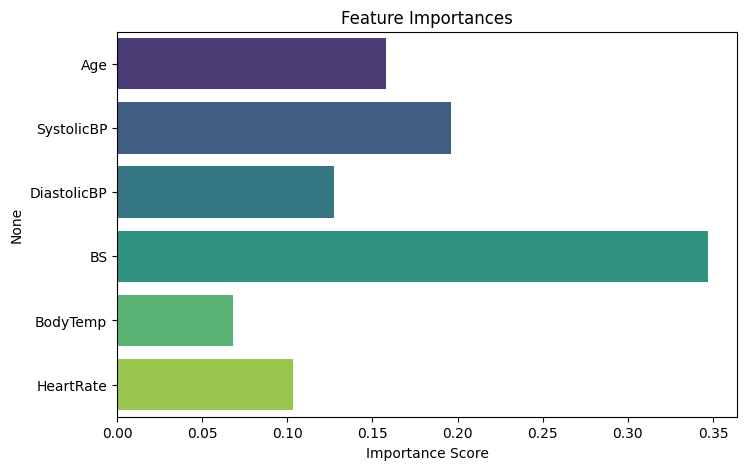

In [8]:
# Only works for tree-based models
rf_clf = final_model.named_steps["clf"]
importances = rf_clf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.show()

In [9]:
os.makedirs("model", exist_ok=True)

# Save model + label encoder together
model_bundle = {
    "model": final_model,
    "label_encoder": le,
    "feature_names": list(X.columns)
}

joblib.dump(model_bundle, "model/model.pkl")
print("✅ Model saved to model/model.pkl")

✅ Model saved to model/model.pkl


In [10]:
bundle = joblib.load("model/model.pkl")
model  = bundle["model"]
le     = bundle["label_encoder"]

# Example: one new patient
sample = pd.DataFrame([{
    "Age": 28,
    "SystolicBP": 140,
    "DiastolicBP": 90,
    "BS": 15.0,
    "BodyTemp": 98,
    "HeartRate": 80
}])

pred_encoded = model.predict(sample)[0]
pred_proba   = model.predict_proba(sample)[0]

print("Prediction:", le.inverse_transform([pred_encoded])[0])
print("Probabilities:")
for cls, prob in zip(le.classes_, pred_proba):
    print(f"  {cls}: {prob:.2%}")

Prediction: high risk
Probabilities:
  high risk: 99.00%
  low risk: 0.00%
  mid risk: 1.00%
